# Tech Challenge - Fase 1: EXTRA - Detecção de Câncer de Mama via CNN

Este notebook contém a exploração de dados, o pré-processamento de imagens e a criação de modelos preditivos baseados em Redes Neurais Convolucionais (CNN) para detectar a presença de câncer de mama em radiografias. 

O objetivo principal é construir uma ferramenta de suporte à decisão médica para otimizar o tempo de triagem. Lembre-se: o modelo serve como auxílio diagnóstico, e a palavra final sempre cabe ao profissional de saúde.

In [146]:
import os
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import glob
import cv2
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization, Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling, GlobalMaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

tf.get_logger().setLevel('ERROR')

### 1. Aquisição dos Dados
Utilizamos a biblioteca oficial do Kaggle para automatizar o download do dataset de imagens, garantindo que o repositório permaneça leve e reprodutível.

In [2]:
print("\nBaixando dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")
print(f"Dataset mapeado em: {dataset_path}")


Baixando dataset via kagglehub...


100%|██████████| 4.95G/4.95G [02:48<00:00, 31.5MB/s]  

Extracting files...


Dataset mapeado em: /root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1


### 2. Cruzamento de Metadados Clínicos e Pipeline de Carregamento
Datasets médicos complexos exigem que o diagnóstico seja extraído de registros tabulares. Cruzamos os arquivos CSV de metadados para obter a classe alvo (`pathology`), unificando tumores e calcificações. Mapeamos os registros para os arquivos de imagem físicos e utilizamos a API `tf.data` para construir um pipeline assíncrono de alto desempenho, dividindo os dados estritamente em Treino, Validação e Teste.

In [115]:
BATCH_SIZE = 32
IMG_SIZE_CNN = (224, 224)
IMG_SIZE_DENSE = (512, 512)

# 1. Carregar CSVs
caminho_csv = os.path.join(dataset_path, 'csv')
df_train = pd.concat([pd.read_csv(os.path.join(caminho_csv, f)) for f in ['calc_case_description_train_set.csv', 'mass_case_description_train_set.csv']], ignore_index=True)
df_test = pd.concat([pd.read_csv(os.path.join(caminho_csv, f)) for f in ['calc_case_description_test_set.csv', 'mass_case_description_test_set.csv']], ignore_index=True)
df_dicom = pd.read_csv(os.path.join(caminho_csv, 'dicom_info.csv'))

# 2. Preparar chave de cruzamento
def extrair_uids(path):
    return [p for p in str(path).split('/') if p.startswith('1.3.6')]

coluna_alvo = 'cropped image file path'

df_train['uids'] = df_train[coluna_alvo].apply(extrair_uids)
df_test['uids'] = df_test[coluna_alvo].apply(extrair_uids)
df_dicom['uids'] = df_dicom['file_path'].apply(extrair_uids)

# 3. Cruzar dados
df_train_m = df_train.explode('uids').merge(df_dicom.explode('uids'), on='uids', suffixes=('', '_dicom'))
df_test_m = df_test.explode('uids').merge(df_dicom.explode('uids'), on='uids', suffixes=('', '_dicom'))

# 4. Construir caminho real
def construir_caminho(img_path):
    sufixo = "/".join(str(img_path).split('/')[-2:])
    caminho_completo = os.path.join(dataset_path, 'jpeg', sufixo)
    return caminho_completo if os.path.exists(caminho_completo) else None

df_train_m['caminho_real'] = df_train_m['image_path'].apply(construir_caminho)
df_test_m['caminho_real'] = df_test_m['image_path'].apply(construir_caminho)

# 5. Limpeza e Rotulagem
df_train = df_train_m.dropna(subset=['caminho_real']).drop_duplicates(subset=[coluna_alvo])
df_test = df_test_m.dropna(subset=['caminho_real']).drop_duplicates(subset=[coluna_alvo])

df_train['label'] = df_train['pathology'].apply(lambda x: 1 if 'MALIGNANT' in str(x) else 0)
df_test['label'] = df_test['pathology'].apply(lambda x: 1 if 'MALIGNANT' in str(x) else 0)

print(f"Registros de Treino validados (Recortes): {len(df_train)}")
print(f"Registros de Teste validados (Recortes): {len(df_test)}")

# 6. Pipeline
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['label'])

is_cnn = True
def carregar_img(caminho, rotulo):
    img = tf.io.read_file(caminho)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE_CNN if is_cnn else IMG_SIZE_DENSE)
    return img, tf.expand_dims(tf.cast(rotulo, tf.float32), axis=-1)

# Dataset CNN
dataset_train_cnn = tf.data.Dataset.from_tensor_slices((df_train['caminho_real'].values, df_train['label'].values)).map(carregar_img, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
dataset_val_cnn = tf.data.Dataset.from_tensor_slices((df_val['caminho_real'].values, df_val['label'].values)).map(carregar_img, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
dataset_test_cnn = tf.data.Dataset.from_tensor_slices((df_test['caminho_real'].values, df_test['label'].values)).map(carregar_img, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

# Dataset DenseNet
is_cnn = False
dataset_train_densenet = tf.data.Dataset.from_tensor_slices((df_train['caminho_real'].values, df_train['label'].values)).map(carregar_img, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
dataset_val_densenet = tf.data.Dataset.from_tensor_slices((df_val['caminho_real'].values, df_val['label'].values)).map(carregar_img, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
dataset_test_densenet = tf.data.Dataset.from_tensor_slices((df_test['caminho_real'].values, df_test['label'].values)).map(carregar_img, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

Registros de Treino validados (Recortes): 2863
Registros de Teste validados (Recortes): 704


In [116]:
def avaliar_balanceamento(dataset, nome_dataset):
    print(f"--- Analisando o Dataset de {nome_dataset} ---")
    
    todos_os_labels = []
    
    for _, labels_batch in dataset:
        todos_os_labels.extend(labels_batch.numpy())
        
    todos_os_labels = np.array(todos_os_labels)
    total_imagens = len(todos_os_labels)
    
    # Conta quantos 0s (Benigno) e 1s (Maligno) existem
    qtd_benigno = np.sum(todos_os_labels == 0)
    qtd_maligno = np.sum(todos_os_labels == 1)
    
    # Calcula as porcentagens
    perc_benigno = (qtd_benigno / total_imagens) * 100
    perc_maligno = (qtd_maligno / total_imagens) * 100
    
    print(f"Total de imagens: {total_imagens}")
    print(f"Benignos: {qtd_benigno} ({perc_benigno:.1f}%)")
    print(f"Malignos: {qtd_maligno} ({perc_maligno:.1f}%)\n")

avaliar_balanceamento(dataset_train, "Treino")
avaliar_balanceamento(dataset_val, "Validação")
avaliar_balanceamento(dataset_test, "Teste")

--- Analisando o Dataset de Treino ---
Total de imagens: 2290
Benignos: 1345 (58.7%)
Malignos: 945 (41.3%)

--- Analisando o Dataset de Validação ---
Total de imagens: 573
Benignos: 337 (58.8%)
Malignos: 236 (41.2%)

--- Analisando o Dataset de Teste ---
Total de imagens: 704
Benignos: 428 (60.8%)
Malignos: 276 (39.2%)



### 3. Exploração Visual das Radiografias
Visualizamos uma amostra do lote de treinamento para confirmar o carregamento correto das imagens e inspecionar visualmente as características das classes.

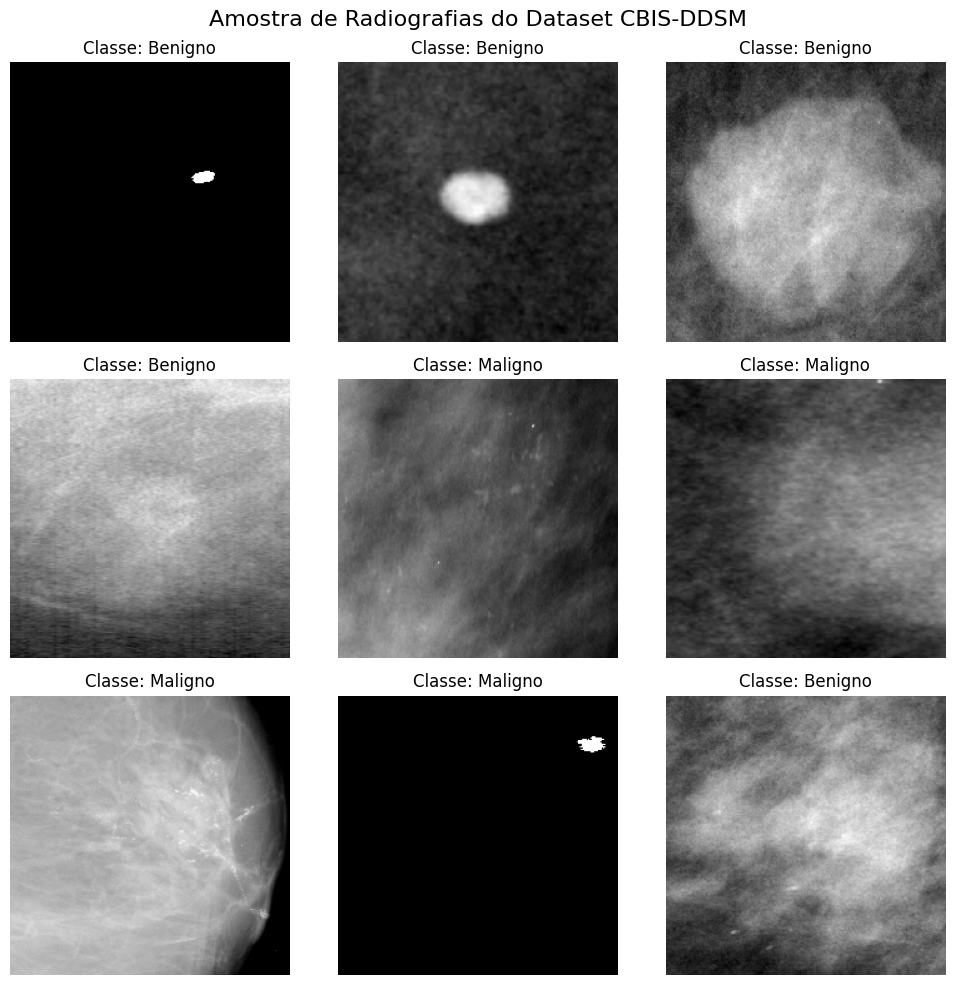

In [105]:
class_names = ['Benigno', 'Maligno']
plt.figure(figsize=(10, 10))
for images, labels in dataset_train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        classe_idx = int(labels[i].numpy()[0])
        plt.title(f"Classe: {class_names[classe_idx]}")
        plt.axis("off")
        
plt.suptitle("Amostra de Radiografias do Dataset CBIS-DDSM", fontsize=16)
plt.tight_layout()
plt.show()

### 4. Otimização e Data Augmentation
Aplicamos o armazenamento em cache para acelerar o processamento dos lotes e introduzimos transformações geométricas (rotação e zoom) no treino para evitar o *overfitting*.

In [161]:
# Otimizar o pipeline de dados para evitar gargalos de I/O
AUTOTUNE = tf.data.AUTOTUNE
dataset_train = dataset_train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dataset_val = dataset_val.cache().prefetch(buffer_size=AUTOTUNE)
dataset_test = dataset_test.cache().prefetch(buffer_size=AUTOTUNE)

# Construção do pipeline de Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=42),
    layers.RandomRotation(0.2, seed=42),
    layers.RandomZoom(0.1, seed=42),
])

### 5. Arquitetura da Rede Neural Convolucional (CNN)
Construímos a rede neural com camadas de convolução para a extração progressiva de padrões visuais (como bordas e densidades), finalizando com camadas densas para a classificação binária.

In [121]:
# Estruturando o modelo Sequencial
modelo_cnn = Sequential([
    # Camada de Entrada e Pré-processamento embarcado
    Input(shape=(IMG_SIZE_CNN[0], IMG_SIZE_CNN[1], 3)),
    data_augmentation,
    Rescaling(1./255), # Normalização dos pixels de 0-255 para 0-1
    
    # Primeiro bloco convolucional
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Segundo bloco convolucional
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Terceiro bloco convolucional
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Quarto bloco convolucional
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Transição de matriz 2D para vetor 1D
    Flatten(),
    
    # Rede Densa para tomada de decisão
    Dense(256, activation='relu'),
    Dropout(0.5), # Desliga 50% dos neurônios no treino para forçar a generalização
    Dense(1, activation='sigmoid') # Função Sigmoid para saída binária (0 a 1)
])

# Exibe o sumário com a quantidade de parâmetros da rede
modelo_cnn.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,665,281 (25.43 MB)

 Trainable params: 6,664,577 (25.42 MB)

 Non-trainable params: 704 (2.75 KB)

In [147]:
# Carregar o DenseNet121
base_model = DenseNet121(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_SIZE_DENSE[0], IMG_SIZE_DENSE[1], 3))

# Descongelar as últimas camadas da DenseNet para o Fine Tunning
base_model.trainable = False 
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Cabeçalho de Classificação
x = base_model.output
x = GlobalMaxPooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Previne overfitting
predicoes = Dense(1, activation='sigmoid')(x)

# Compilar o Modelo
modelo_densenet = Model(inputs=base_model.input, outputs=predicoes)

# Usar um learning rate menor no fine-tuning
modelo_densenet.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

### 6. Compilação e Treinamento do Modelo
Definimos a função de perda e o otimizador da rede, e iniciamos o treinamento utilizando a técnica de *Early Stopping* para interromper o processo caso o modelo comece a decorar os dados (*overfitting*).

In [126]:
# Cálcular pesos para corrigir desbalanceamento
neg, pos = np.bincount(df_train['label'])
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}

# Compilar o modelo configurando as métricas de interesse
modelo_cnn.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

# Configurar Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Configurar callback de otimização
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6, verbose=1
)

# Treinar Rede Neural
print("Iniciando o treinamento da CNN...")
history_cnn = modelo_cnn.fit(
    dataset_train_cnn,
    validation_data=dataset_val_cnn,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler],
    class_weight=class_weights # Penaliza erro na classe minoritária
)

Iniciando o treinamento da CNN...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 490ms/step - accuracy: 0.4262 - loss: 0.6987 - recall_4: 0.9418 - val_accuracy: 0.4555 - val_loss: 0.7390 - val_recall_4: 0.3051 - learning_rate: 0.0010
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 489ms/step - accuracy: 0.4581 - loss: 0.7029 - recall_4: 0.8508 - val_accuracy: 0.5742 - val_loss: 0.6774 - val_recall_4: 0.5000 - learning_rate: 0.0010
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 490ms/step - accuracy: 0.4227 - loss: 0.7052 - recall_4: 0.9587 - val_accuracy: 0.4241 - val_loss: 1.0983 - val_recall_4: 0.9492 - learning_rate: 0.0010
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 491ms/step - accuracy: 0.4127 - loss: 0.6929 - recall_4: 1.0000 - val_accuracy: 0.4136 - val_loss: 0.6979 - val_recall_4: 0.9492 - learning_rate: 0.0010
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.4017 - loss: 0.6903 - recall_4: 1.0000
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
72/7

In [148]:
# Configurar Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,              
    restore_best_weights=True
)

# Treinar DenseNet
print("Iniciando o treino com Transfer Learning...")
history_densenet = modelo_densenet.fit(
    dataset_train_densenet,
    validation_data=dataset_val_densenet,
    epochs=15,
    callbacks=[early_stopping]
)

Iniciando o treino com Transfer Learning...
Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.5550 - loss: 2.5633 - val_accuracy: 0.6021 - val_loss: 1.0371
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.5764 - loss: 1.5280 - val_accuracy: 0.6126 - val_loss: 0.9757
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.6205 - loss: 1.0190 - val_accuracy: 0.6213 - val_loss: 0.7313
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.6236 - loss: 0.8159 - val_accuracy: 0.6230 - val_loss: 0.7101
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.6445 - loss: 0.6894 - val_accuracy: 0.6143 - val_loss: 0.6817
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.6572 - loss: 0.6389 - val_accuracy: 0.5951 - val_loss: 0.6680
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.6834 - loss: 0.6073 - val_accuracy: 0.6318 - val_loss: 0.6630
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.71

### 7. Curvas de Aprendizado
Visualizamos graficamente a evolução da acurácia e a redução do erro (loss) em cada época para validar o comportamento do modelo durante o treinamento.

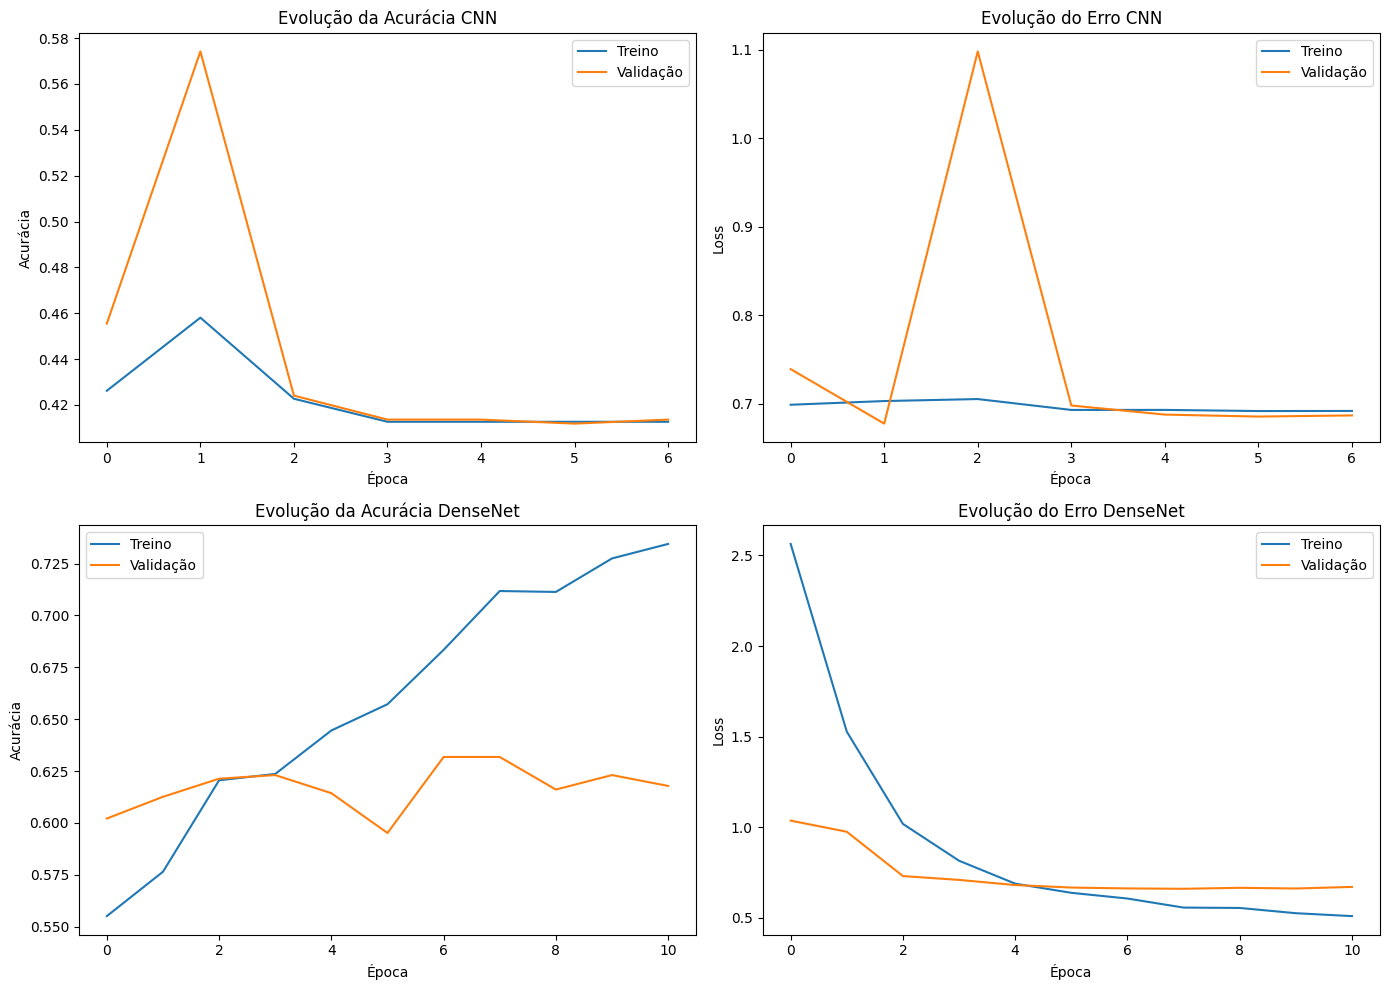

In [152]:
# Plotar as curvas de Acurácia e Loss
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Curva de Acurácia
axes[0].plot(history_cnn.history['accuracy'], label='Treino')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validação')
axes[0].set_title('Evolução da Acurácia CNN')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

# Curva de Loss
axes[1].plot(history_cnn.history['loss'], label='Treino')
axes[1].plot(history_cnn.history['val_loss'], label='Validação')
axes[1].set_title('Evolução do Erro CNN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Curva de Acurácia
axes[2].plot(history_densenet.history['accuracy'], label='Treino')
axes[2].plot(history_densenet.history['val_accuracy'], label='Validação')
axes[2].set_title('Evolução da Acurácia DenseNet')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Acurácia')
axes[2].legend()

# Curva de Loss
axes[3].plot(history_densenet.history['loss'], label='Treino')
axes[3].plot(history_densenet.history['val_loss'], label='Validação')
axes[3].set_title('Evolução do Erro DenseNet')
axes[3].set_xlabel('Época')
axes[3].set_ylabel('Loss')
axes[3].legend()

plt.tight_layout()
plt.show()

### 8. Avaliação Final e Métricas Clínicas
Avaliamos a capacidade preditiva da CNN nos dados de validação, priorizando métricas como Recall e F1-Score para minimizar falsos negativos, e geramos a Matriz de Confusão.

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
--- Desempenho do Modelo CNN (Dados de Teste) ---
Acurácia:  0.5185
Recall:    0.3877
F1-Score:  0.3870



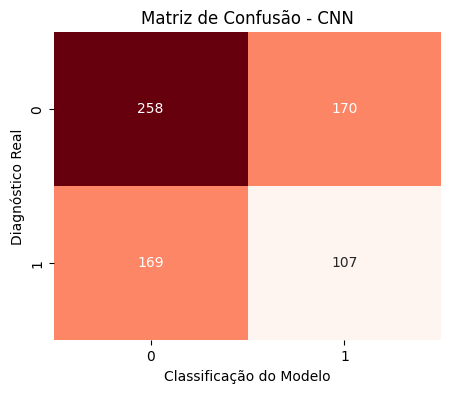

--- Desempenho do Modelo DenseNet (Dados de Teste) ---
Acurácia:  0.6023
Recall:    0.5471
F1-Score:  0.5189



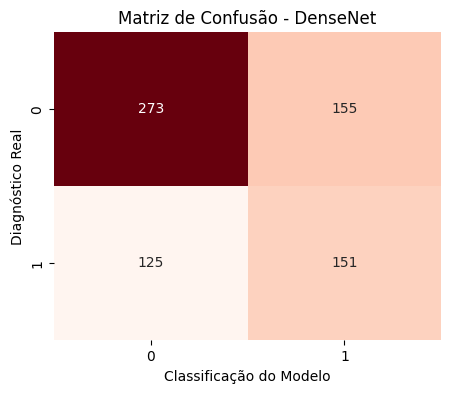

In [154]:
# Extrair rótulos reais e gerar predições para o conjunto de teste
y_reais_cnn = np.concatenate([y for x, y in dataset_test_cnn], axis=0)
y_reais_densenet = np.concatenate([y for x, y in dataset_test_densenet], axis=0)
predicoes_prob_cnn = modelo_cnn.predict(dataset_test_cnn)
predicoes_prob_densenet = modelo_densenet.predict(dataset_test_densenet)

# Converter as probabilidades em classes binárias (limiar de 0.5)
predicoes_cnn = (predicoes_prob_cnn > 0.5).astype(int)
predicoes_densenet = (predicoes_prob_densenet > 0.5).astype(int)

# Calcular as métricas
acuracia_cnn = accuracy_score(y_reais_cnn, predicoes_cnn)
recall_cnn = recall_score(y_reais_cnn, predicoes_cnn)
f1_cnn = f1_score(y_reais_cnn, predicoes_cnn)
acuracia_densenet = accuracy_score(y_reais_densenet, predicoes_densenet)
recall_densenet = recall_score(y_reais_densenet, predicoes_densenet)
f1_densenet = f1_score(y_reais_densenet, predicoes_densenet)

print(f"--- Desempenho do Modelo CNN (Dados de Teste) ---")
print(f"Acurácia:  {acuracia_cnn:.4f}")
print(f"Recall:    {recall_cnn:.4f}")
print(f"F1-Score:  {f1_cnn:.4f}\n")

# Matriz de Confusão CNN
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_reais_cnn, predicoes_cnn), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Matriz de Confusão - CNN')
plt.xlabel('Classificação do Modelo')
plt.ylabel('Diagnóstico Real')
plt.show()

print(f"--- Desempenho do Modelo DenseNet (Dados de Teste) ---")
print(f"Acurácia:  {acuracia_densenet:.4f}")
print(f"Recall:    {recall_densenet:.4f}")
print(f"F1-Score:  {f1_densenet:.4f}\n")

# Matriz de Confusão DenseNet
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_reais_densenet, predicoes_densenet), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Matriz de Confusão - DenseNet')
plt.xlabel('Classificação do Modelo')
plt.ylabel('Diagnóstico Real')
plt.show()

### 9. Interpretabilidade Visual (Grad-CAM)
Para garantir a transparência exigida em sistemas de saúde, aplicamos a técnica de Grad-CAM. Em vez de simplesmente entregar um diagnóstico binário, o modelo gera mapas de ativação térmicos que destacam as regiões da radiografia que mais influenciaram a predição, permitindo que a equipe médica valide a lógica da inteligência artificial.

In [155]:
def encontrar_ultima_camada_conv(modelo):
    for camada in reversed(modelo.layers):
        if isinstance(camada, tf.keras.layers.Conv2D) or 'conv2d' in camada.name.lower():
            return camada.name
            
    raise ValueError("Nenhuma camada convolucional (Conv2D) foi encontrada no modelo fornecido.")

In [156]:
def gerar_heatmap_gradcam(img_tensor, modelo, nome_ultima_camada_conv, pred_index=None):
    # Recriar a entrada usando o formato imagem
    input_shape = (img_tensor.shape[1], img_tensor.shape[2], img_tensor.shape[3])
    novo_input = tf.keras.Input(shape=input_shape)
    
    x = novo_input
    saida_conv = None
    
    # Percorrer as camadas do modelo treinado para reconstruir o grafo limpo.
    for camada in modelo.layers:
        if isinstance(camada, tf.keras.Sequential) or 'sequential' in camada.name.lower():
            continue
            
        x = camada(x) # Passa o tensor pela camada mantendo os pesos treinados
        
        if camada.name == nome_ultima_camada_conv:
            saida_conv = x
            
    # Criar o modelo de Grad-CAM com o grafo recriado
    grad_model = tf.keras.Model(inputs=novo_input, outputs=[saida_conv, x])
    
    # Calculo normal dos gradientes
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_tensor, training=False)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalizar
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

Classe real da imagem extraída: Maligno


W0000 00:00:1782798499.295922   11917 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1782798499.296027   11917 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


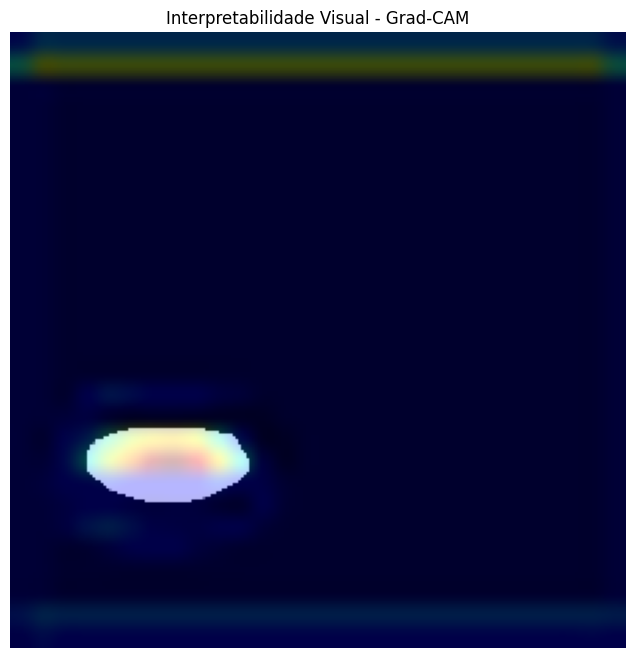

In [164]:
def exibir_gradcam_sobreposto_array(img_array_original, heatmap, alpha=0.4):
    # Redimensionar o heatmap para a escala de 0 a 255
    heatmap = np.uint8(255 * heatmap)
    
    # Criar o mapa de cores
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Redimensionar o heatmap para o tamanho da imagem
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array_original.shape[1], img_array_original.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Sobrepor o heatmap na imagem
    superimposed_img = jet_heatmap * alpha + img_array_original
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Plotar o resultado
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Interpretabilidade Visual - Grad-CAM")
    plt.show()

# Pegar apenas uma imagem e seu rótulo do dataset de teste
img_idx = 2;
for imagens, labels in dataset_val.take(1):
    img_unica = imagens[img_idx]
    label_real = labels[img_idx]
    break

# Preparar imagem e gerar heatmap
img_array_modelo = tf.expand_dims(img_unica, axis=0)
ultima_camada_conv = encontrar_ultima_camada_conv(modelo_cnn)
heatmap = gerar_heatmap_gradcam(img_array_modelo, modelo_cnn, ultima_camada_conv)
img_original_para_exibir = img_unica.numpy().astype("uint8")

# Exibir o resultado final
print(f"Classe real da imagem extraída: {class_names[int(label_real)]}")
exibir_gradcam_sobreposto_array(img_original_para_exibir, heatmap)

## Conclusão Crítica

As avaliações do modelo CNN e do modelo pré-treinado DenseNet121, demonstraram que a arquitetura atual não possui a capacidade preditiva necessária para a complexidade do domínio oncológico (dataset CBIS-DDSM). As métricas no conjunto de validação indicam que os modelos não foram capazes de aprender os padrões, resultando em um desempenho de classificação próximo à aleatoriedade. A aplicação do Grad-CAM confirmou essa fragilidade, revelando a dificuldade da rede básica em focar consistentemente nas lesões sem se confundir com o tecido saudável ou ruídos da imagem.

**O modelo pode ser utilizado na prática clínica?**
Não. Com os resultados atuais de precisão e recall, o uso deste modelo representaria um risco às pacientes, gerando altas taxas de falsos positivos e, o que é pior, falsos negativos. Para que o sistema se torne uma ferramenta viável de triagem, será obrigatório refatorar o pipeline com abordagens mais robustas e técnicas avançadas de balanceamento.